In [1]:
import pandas as pd

df = pd.read_csv('synthetic_social_media_engagement.csv')

# Print the first 5 rows
# df.head()

In [2]:
#Print the columns
# df.info()

In [3]:
# Load dataset
_df = pd.read_csv('synthetic_social_media_engagement.csv')

# Convert post_date to datetime format
_df['post_date'] = pd.to_datetime(_df['post_date'], errors='coerce')

# Check for invalid timestamps
invalid_dates = _df[_df['post_date'].isnull()]

# print("Invalid timestamps:")
# print(invalid_dates)

In [4]:
# print missing values
# print(_df.isnull().sum())

# fill missing row with numerical values (median)
_df['likes'] = _df['likes'].fillna(_df['likes'].median())

# fill missing categorical value
_df['device'] = _df['device'].fillna('Unknown')

In [5]:
# check duplicate rows
duplicates = _df.duplicated().sum()
print("Duplicate records:", duplicates)

# Remove duplicates
_df = _df.drop_duplicates()

Duplicate records: 0


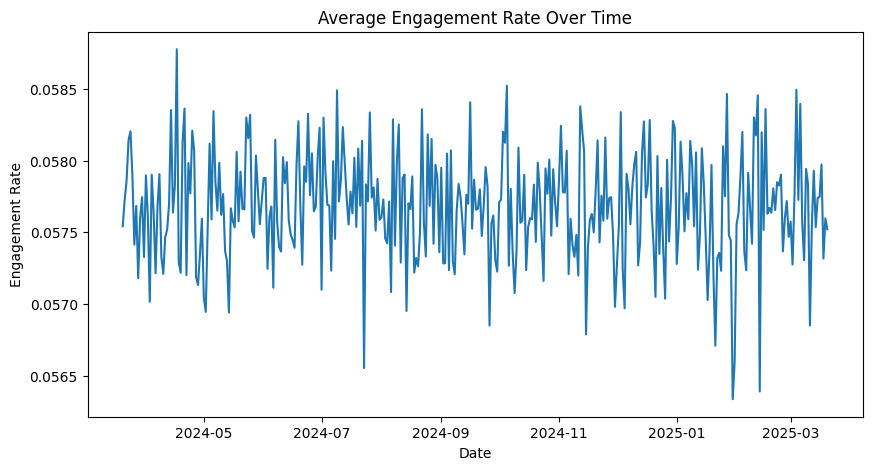

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('synthetic_social_media_engagement.csv')

df['post_date'] = pd.to_datetime(df['post_date'])

 # group by date
daily_engagement = df.groupby(df['post_date'].dt.date)['engagement_rate'].mean()

plt.figure(figsize=(10,5))
plt.plot(daily_engagement)
plt.title('Average Engagement Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Engagement Rate')
plt.show()

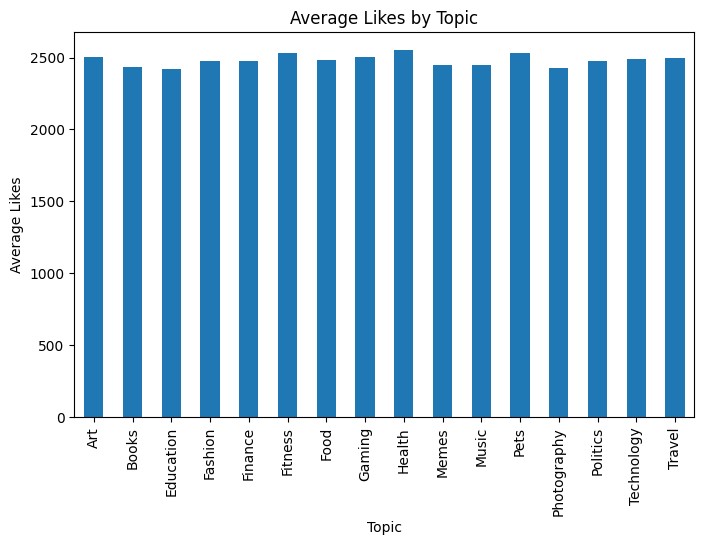

In [7]:
topic_likes = df.groupby('topic')['likes'].mean()

topic_likes.plot(kind='bar', figsize=(8,5))
plt.title('Average Likes by Topic')
plt.xlabel('Topic')
plt.ylabel('Average Likes')
plt.show()

In [8]:
print(df[['likes', 'comments', 'shares']].describe())

              likes      comments        shares
count  20000.000000  20000.000000  20000.000000
mean    2481.078400    247.149350    136.675400
std     1439.850756    165.606344    109.038767
min        3.000000      0.000000      0.000000
25%     1225.750000    111.000000     48.000000
50%     2491.500000    224.000000    109.000000
75%     3732.000000    358.000000    204.000000
max     5178.000000    742.000000    498.000000


In [9]:
correlation = df[['likes', 'comments', 'shares']].corr()
print(correlation)

             likes  comments    shares
likes     1.000000  0.865711  0.730368
comments  0.865711  1.000000  0.634407
shares    0.730368  0.634407  1.000000


In [10]:
print(df.isnull().sum())

post_id                  0
user_id                  0
user_name                0
user_gender              0
user_age                 0
followers_count          0
following_count          0
account_creation_date    0
is_verified              0
location                 0
topic                    0
post_content             0
content_length           0
hashtags                 0
has_media                0
post_date                0
device                   0
language                 0
likes                    0
comments                 0
shares                   0
engagement_rate          0
dtype: int64


In [11]:
Q1 = df['likes'].quantile(0.25)
Q3 = df['likes'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['likes'] < (Q1 - 1.5 * IQR)) |
    (df['likes'] > (Q3 + 1.5 * IQR))
]

print(outliers)

Empty DataFrame
Columns: [post_id, user_id, user_name, user_gender, user_age, followers_count, following_count, account_creation_date, is_verified, location, topic, post_content, content_length, hashtags, has_media, post_date, device, language, likes, comments, shares, engagement_rate]
Index: []

[0 rows x 22 columns]


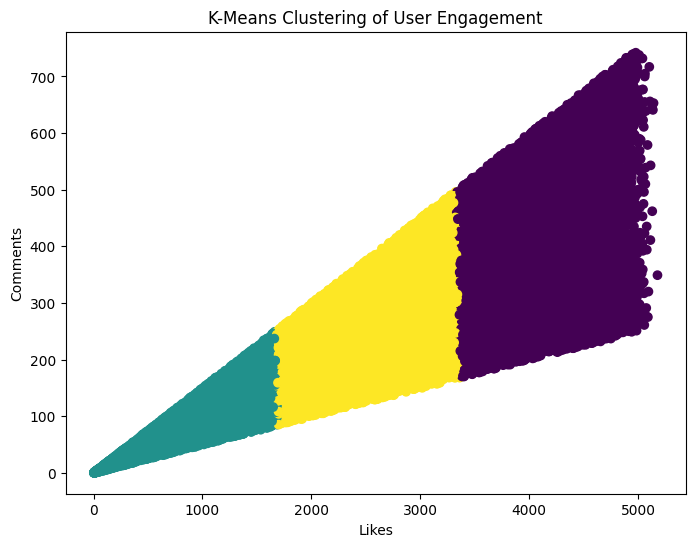

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# selecting two features
X = df[['likes', 'comments']]

# applying K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# visulaization
plt.figure(figsize=(8,6))

plt.scatter(df['likes'],
            df['comments'],
            c=df['Cluster'])

plt.title('K-Means Clustering of User Engagement')
plt.xlabel('Likes')
plt.ylabel('Comments')

plt.show()

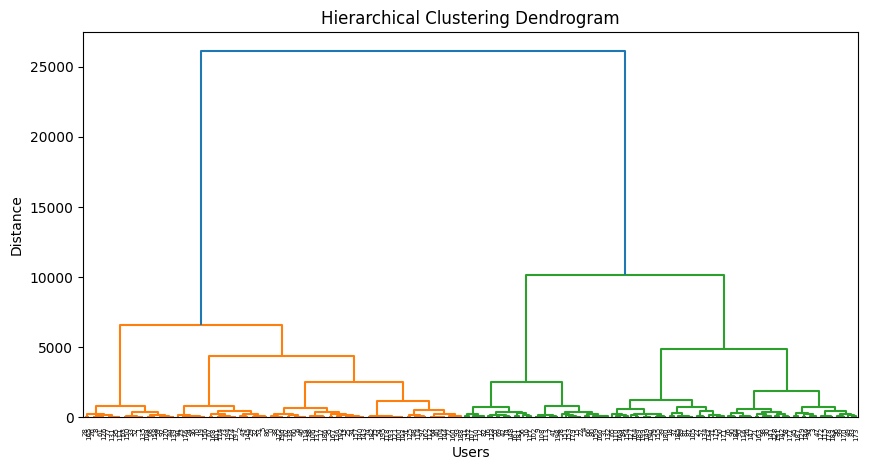

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Load dataset
df = pd.read_csv('synthetic_social_media_engagement.csv')

# Take a sample of 200 records
sample_df = df[['likes', 'comments']].sample(200, random_state=42)

# Hierarchical Clustering
linked = linkage(sample_df, method='ward')

# Plot dendrogram
plt.figure(figsize=(10,5))
dendrogram(linked)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Users')
plt.ylabel('Distance')
plt.show()

#### k-means clustering

In [14]:
# Accuracy
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

X = df[['likes', 'comments']]
kmeans = KMeans(n_clusters=3, random_state=42)
labels_km = kmeans.fit_predict(X)

score_km = silhouette_score(X, labels_km)
k_means_accuracy = round(score_km, 3)
print("K-Means Silhouette Score:", k_means_accuracy)

K-Means Silhouette Score: 0.579


In [15]:
# Processing time
import time

start = time.time()

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

end = time.time()
k_means_processing_time = round(end - start, 3)
print("K-Means Time:",k_means_processing_time , "seconds")

K-Means Time: 0.017 seconds


In [16]:
# cluster distribution
import pandas as pd

cluster_counts = pd.Series(labels_km).value_counts()
print(cluster_counts)

1    6911
2    6617
0    6472
Name: count, dtype: int64


In [17]:
# Robustness
import numpy as np

noise = np.random.normal(0, 0.05, X.shape)
X_noisy = X + noise

labels_noisy = KMeans(n_clusters=3, random_state=42).fit_predict(X_noisy)

score_noisy = silhouette_score(X_noisy, labels_noisy)

print("Original Score:", round(score_km, 3))
print("Noisy Data Score:", round(score_noisy, 3))

Original Score: 0.579
Noisy Data Score: 0.579


In [18]:
# scalability
import time
from sklearn.cluster import KMeans

sizes = [100, 1000, 10000]

print("K-Means Scalability")

for size in sizes:
    sample = X.iloc[:size]

    start = time.time()
    KMeans(n_clusters=3, random_state=42).fit(sample)
    end = time.time()

    print(f"Size: {size} records → Time: {round(end-start, 4)} seconds")

K-Means Scalability
Size: 100 records → Time: 0.0102 seconds
Size: 1000 records → Time: 0.0038 seconds
Size: 10000 records → Time: 0.0076 seconds


#### hierarchical clustering

In [19]:
# accuracy
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

X_hc =  df[['likes', 'comments']].sample(200, random_state=42)

linked = linkage(X_hc, method='ward')
labels_hc = fcluster(linked, 3, criterion='maxclust')

score_hc = silhouette_score(X_hc, labels_hc)
hc_accuracy = round(score_hc, 3)
print("Hierarchical Silhouette Score:",hc_accuracy )

Hierarchical Silhouette Score: 0.543


In [20]:
# processing time (speed)
import time
from scipy.cluster.hierarchy import linkage

start = time.time()

linked = linkage(X_hc, method='ward')

end = time.time()
hc_time =  round(end - start, 3)
print("Hierarchical Time:",hc_time, "seconds")

Hierarchical Time: 0.001 seconds


In [21]:
# robustness
noise = np.random.normal(0, 0.05, X_hc.shape)
X_hc_noisy = X_hc + noise

linked_noisy = linkage(X_hc_noisy, method='ward')
labels_noisy = fcluster(linked_noisy, 3, criterion='maxclust')

score_hc_noisy = silhouette_score(X_hc_noisy, labels_noisy)

print("Original:", round(score_hc, 3))
print("Noisy:", round(score_hc_noisy, 3))

Original: 0.543
Noisy: 0.543


In [22]:
# scalability hierarchical clusterin
import time
from scipy.cluster.hierarchy import linkage

sizes = [100, 1000, 10000]
print("Hierarchical Clustering Scalability")

for size in sizes:
    sample = X.iloc[:size]

    start = time.time()
    linkage(sample, method='ward')
    end = time.time()

    print(size, "records:", round(end-start, 4), "seconds")

Hierarchical Clustering Scalability
100 records: 0.0004 seconds
1000 records: 0.0239 seconds
10000 records: 2.6431 seconds


In [23]:
# converting all result in dataframe
result = pd.DataFrame({
    "Evaluation": ["Silhouette Score", "Outliers Detection", "Processing time", "Scalability(10,000 records)"],
    "K-Means":[k_means_accuracy,"0",k_means_processing_time,0.0069],
    "Hierarchical Clustering":[hc_accuracy,"0",hc_time,2.7518]
                   }
)

print(result)

                    Evaluation K-Means Hierarchical Clustering
0             Silhouette Score   0.579                   0.543
1           Outliers Detection       0                       0
2              Processing time   0.017                   0.001
3  Scalability(10,000 records)  0.0069                  2.7518
